# Visualize LowResPT Training Metrics

Reads the latest PyTorch Lightning `metrics.csv` from the `outputs/` directory and plots training/validation loss over steps and epochs.

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')

In [2]:
# Find the latest version directory under outputs/
outputs_root = Path('outputs')
version_dirs = sorted(outputs_root.glob('*/version_*'), key=lambda p: int(p.name.split('_')[-1]))
print('Found versions:')
for v in version_dirs:
    print(' ', v)

latest = version_dirs[-2]
metrics_file = latest / 'metrics.csv'
print(f'\nUsing: {metrics_file}')

Found versions:
  outputs/low_res_pt/version_0
  outputs/low_res_pt/version_1

Using: outputs/low_res_pt/version_0/metrics.csv


In [3]:
# Load metrics.csv — Lightning logs train and val in separate rows
raw = pd.read_csv(metrics_file)
print('Raw shape:', raw.shape)
print('Columns:', raw.columns.tolist())
display(raw.head(10))

Raw shape: (1320, 16)
Columns: ['epoch', 'hidden_tokens', 'hide_ratio_actual', 'lr', 'selected_tokens', 'step', 'train_cont_mse', 'train_full_mse', 'train_hid_mse', 'train_line_mse', 'train_loss', 'train_vis_mse', 'val_hid_loss', 'val_loss', 'val_vis_loss', 'valid_tokens']


,epoch,hidden_tokens,hide_ratio_actual,lr,selected_tokens,step,train_cont_mse,train_full_mse,train_hid_mse,train_line_mse,train_loss,train_vis_mse,val_hid_loss,val_loss,val_vis_loss,valid_tokens
0,0,6752.0,0.950049,0.00001,7107.0,9,1.225753,1.339110,1.339286,4.880994,1.678847,1.537541,NaN,NaN,NaN,13708.0
1,0,6772.0,0.946868,0.00002,7152.0,19,0.724843,0.834849,0.856363,4.781612,1.212360,1.114014,NaN,NaN,NaN,13793.0
2,0,NaN,NaN,NaN,NaN,22,NaN,NaN,NaN,NaN,NaN,NaN,0.538179,0.539884,0.573226,NaN
3,1,6785.0,0.948023,0.00003,7157.0,29,0.513784,0.606682,0.649707,4.186734,0.951407,0.601757,NaN,NaN,NaN,13805.0
4,1,6784.0,0.948546,0.00004,7152.0,39,0.434973,0.521941,0.564384,4.176935,0.857786,0.591398,NaN,NaN,NaN,13793.0
5,1,NaN,NaN,NaN,NaN,45,NaN,NaN,NaN,NaN,NaN,NaN,0.419920,0.421199,0.450758,NaN
6,2,6797.0,0.950629,0.00005,7150.0,49,0.373930,0.444675,0.485194,3.700448,0.743013,0.549734,NaN,NaN,NaN,13791.0
7,2,6808.0,0.950307,0.00006,7164.0,59,0.365228,0.423949,0.490237,3.879691,0.763369,0.472242,NaN,NaN,NaN,13817.0
8,2,NaN,NaN,NaN,NaN,68,NaN,NaN,NaN,NaN,NaN,NaN,0.399560,0.398659,0.381713,NaN
9,3,6805.0,0.954284,0.00007,7131.0,69,0.340930,0.395860,0.466497,3.862666,0.736809,0.431330,NaN,NaN,NaN,13753.0


In [4]:
# Split into train rows (have train_loss) and val rows (have val_loss)
train_df = raw.dropna(subset=['train_loss']).copy()
val_df   = raw.dropna(subset=['val_loss']).copy()

# Fill epoch forward so val rows inherit their epoch
raw_filled = raw.copy()
raw_filled['epoch'] = raw_filled['epoch'].ffill().astype(int)
train_df = raw_filled.dropna(subset=['train_loss']).copy()
val_df   = raw_filled.dropna(subset=['val_loss']).copy()

print(f'Train rows: {len(train_df)}, Val rows: {len(val_df)}')

Train rows: 920, Val rows: 400


In [5]:
# Smoothing helpers
def sma(series, window=None):
    if window is None:
        window = max(5, int(len(series) * 0.02))
    return series.rolling(window=window, min_periods=1).mean()

def ewm(series, alpha=0.1):
    return series.ewm(alpha=alpha).mean()

train_df = train_df.sort_values('step').reset_index(drop=True)
val_df   = val_df.sort_values('step').reset_index(drop=True)

train_df['train_loss_sma'] = sma(train_df['train_loss'])
train_df['train_loss_ewm'] = ewm(train_df['train_loss'])

if 'train_full_mse' in train_df.columns:
    train_df['train_full_mse_sma'] = sma(train_df['train_full_mse'])
    train_df['train_full_mse_ewm'] = ewm(train_df['train_full_mse'])

In [6]:
# Epoch-level aggregation
epoch_train = train_df.groupby('epoch')['train_loss'].agg(['mean','std']).rename(columns={'mean':'train_loss_mean','std':'train_loss_std'})
epoch_val   = val_df.groupby('epoch')['val_loss'].agg(['mean','std']).rename(columns={'mean':'val_loss_mean','std':'val_loss_std'})
epoch_summary = epoch_train.join(epoch_val, how='outer')
print('Epoch summary:')
display(epoch_summary)

Epoch summary:


,train_loss_mean,train_loss_std,val_loss_mean,val_loss_std
epoch,,,,
0,1.445603,0.329856,0.539884,NaN
1,0.904596,0.066200,0.421199,NaN
2,0.753191,0.014394,0.398659,NaN
3,0.735253,0.027327,0.381142,NaN
4,0.716443,0.025507,0.362193,NaN
...,...,...,...,...
395,0.079533,0.008762,0.066256,NaN
396,0.089400,0.010872,0.063517,NaN
397,0.082517,0.002696,0.059636,NaN


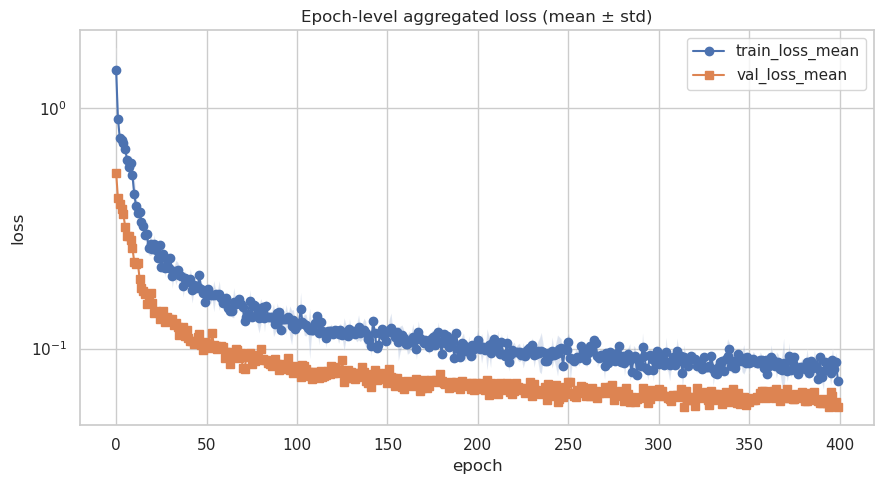

In [7]:
# Plot 1: Epoch-level aggregated train vs val loss
epochs = epoch_summary.index.values

fig, ax = plt.subplots(figsize=(9, 5))

if 'train_loss_mean' in epoch_summary.columns:
    m, s = epoch_summary['train_loss_mean'].values, epoch_summary['train_loss_std'].fillna(0).values
    ax.plot(epochs, m, marker='o', label='train_loss_mean')
    ax.fill_between(epochs, m - s, m + s, alpha=0.2)

if 'val_loss_mean' in epoch_summary.columns:
    m, s = epoch_summary['val_loss_mean'].values, epoch_summary['val_loss_std'].fillna(0).values
    ax.plot(epochs, m, marker='s', label='val_loss_mean')
    ax.fill_between(epochs, m - s, m + s, alpha=0.2)

ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_yscale('log')
ax.set_title('Epoch-level aggregated loss (mean ± std)')
ax.legend()
plt.tight_layout()
plt.show()

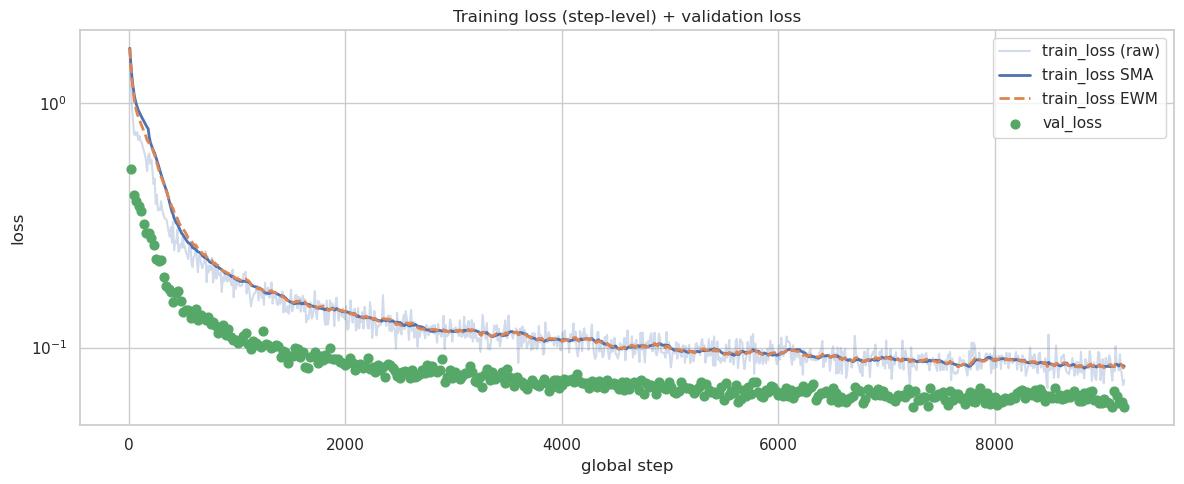

In [8]:
# Plot 2: Step-level train_loss with smoothing + val_loss overlay
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train_df['step'], train_df['train_loss'], color='C0', alpha=0.25, label='train_loss (raw)')
ax.plot(train_df['step'], train_df['train_loss_sma'], color='C0', linewidth=2, label='train_loss SMA')
ax.plot(train_df['step'], train_df['train_loss_ewm'], color='C1', linestyle='--', linewidth=2, label='train_loss EWM')

if not val_df.empty:
    ax.scatter(val_df['step'], val_df['val_loss'], color='C2', s=40, zorder=5, label='val_loss')

ax.set_xlabel('global step')
ax.set_ylabel('loss')
ax.set_title('Training loss (step-level) + validation loss')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

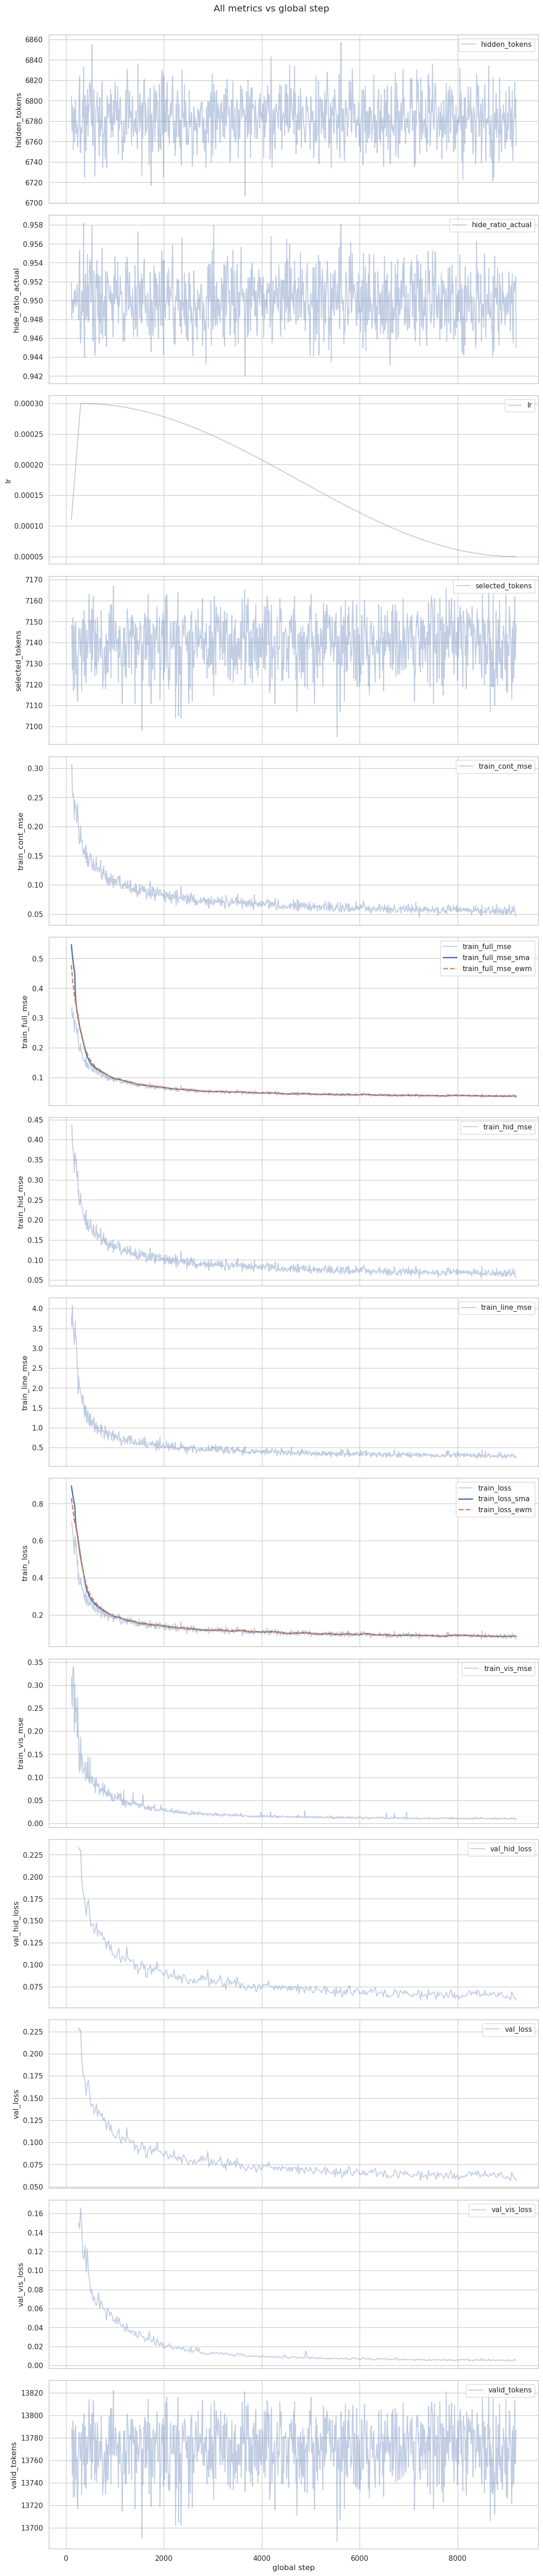

In [9]:
# Plot 3: All numeric metrics as subplots (step-level)
skip = {'epoch', 'step', 'train_loss_sma', 'train_loss_ewm', 'train_full_mse_sma', 'train_full_mse_ewm'}
metric_bases = [c for c in raw.columns if c not in skip and raw[c].notna().any()]

n = len(metric_bases)
fig, axs = plt.subplots(n, 1, figsize=(12, 4 * n), sharex=True)
if n == 1:
    axs = [axs]
skip_step = 10
for ax, col in zip(axs, metric_bases):
    # Use the appropriate sub-dataframe
    if col in train_df.columns and train_df[col].notna().any():
        sub = train_df
    elif col in val_df.columns and val_df[col].notna().any():
        sub = val_df
    else:
        sub = raw_filled

    sub_clean = sub.dropna(subset=[col])
    ax.plot(sub_clean['step'][skip_step:], sub_clean[col][skip_step:], color='C0', alpha=0.35, label=col)

    # Overlay smoothed versions if available
    for suf, color, ls in [('_sma', 'C0', '-'), ('_ewm', 'C1', '--')]:
        sc = col + suf
        if sc in train_df.columns and train_df[sc].notna().any():
            ax.plot(train_df['step'][skip_step:], train_df[sc][skip_step:], color=color, linestyle=ls, linewidth=2, label=sc)
    #ax.set_yscale('log')
    ax.set_ylabel(col)
    ax.legend(loc='upper right')
    ax.grid(True)

axs[-1].set_xlabel('global step')
plt.suptitle('All metrics vs global step', y=1.002)
plt.tight_layout()
plt.show()